In [1]:
import plotly.express as px
import numpy as np
import os
import re
import warnings
import pandas as pd


# --------------------------------------------------------------------
# CONFIG: Variable names with all capital letters are set in this cell 
# --------------------------------------------------------------------

# Set this to whatever you want; this is the default:
SUBJECT_ID = "Subject-03_Hill-Condition"


OUTPUT_DIR = "walk_segmented_csvs"
EXPECTED_TRIALS = 20

# Folder location of the export. Inside the directory you provide should be all of the csv files we expect to work with
TARGET_DIR = '/Users/trentonwirth/Desktop/stair-hill_experiment/s3/s3_hill-condition-2025-11-13_04-07-47-fba7e068/neon_player/exports/000_s3_hill-condition-annotated'

if TARGET_DIR:
    print(TARGET_DIR)
else: 
    print('Target directory doesn not exist')

# if we want to save the output file here from "Run All", make SAVE_OUTPUT = True
SAVE_OUTPUT = False

/Users/trentonwirth/Desktop/stair-hill_experiment/s3/s3_hill-condition-2025-11-13_04-07-47-fba7e068/neon_player/exports/000_s3_hill-condition-annotated


### Load in all CSVs

In [2]:
# 2. Load in csv's

# Load IMU data
imu_df = pd.read_csv(f'{TARGET_DIR}/imu.csv')
# Load gaze positions data
gaze_df = pd.read_csv(f'{TARGET_DIR}/gaze_positions.csv')
# Load in blink data
blinks_df = pd.read_csv(f'{TARGET_DIR}/blinks.csv')
# Load in trial start/end data via annotations.csv file
annotations_df = pd.read_csv(f'{TARGET_DIR}/annotations.csv')

print("IMU data head:")
print(imu_df.head())
print("\nGaze positions data head:")
print(gaze_df.head())

IMU data head:
        timestamp [ns]  gyro x [deg/s]  gyro y [deg/s]  gyro z [deg/s]  \
0  1762981668783083151       -2.956390       -0.019073       -0.501633   
1  1762981668792836151       -2.040863       -0.080109       -0.745773   
2  1762981668802589151       -1.670837        0.102997       -0.627518   
3  1762981668812342151       -0.820160        0.652313       -0.501633   
4  1762981668821796151       -0.879288        0.833511       -0.684738   

   acceleration x [G]  acceleration y [G]  acceleration z [G]  roll [deg]  \
0           -0.006836           -0.056763            0.993530    0.420239   
1            0.001465           -0.061646            1.011108    0.415121   
2            0.004395           -0.064087            1.011597    0.411691   
3            0.000488           -0.062622            1.002319    0.408705   
4            0.015625           -0.062622            0.995483    0.405817   

   pitch [deg]   yaw [deg]  quaternion w  quaternion x  quaternion y  \
0    

### Synchronize Gaze and IMU Data

In [3]:
# --- Synchronize gaze to IMU---
imu_df_sorted = imu_df.sort_values('timestamp [ns]')
gaze_df_sorted = gaze_df.sort_values('timestamp [ns]')

merged_df = pd.merge_asof(
    imu_df_sorted,
    gaze_df_sorted[['timestamp [ns]', 'elevation [deg]']],
    on='timestamp [ns]',
    direction='nearest'
    # tolerance=10000  # optional
)

# Gaze angle
merged_df['gaze angle [deg]'] = merged_df['pitch [deg]'] + merged_df['elevation [deg]']

# Add a time column in seconds relative to the merged dataframe start
start_ns = merged_df['timestamp [ns]'].iloc[0]
merged_df['time_sec'] = (merged_df['timestamp [ns]'] - start_ns) / 1e9

# This is the version WITHOUT blink gaps (include time_sec)
gaze_angle_noblink_df = merged_df[['timestamp [ns]', 'gaze angle [deg]', 'pitch [deg]', 'elevation [deg]', 'time_sec']].copy()

print(f"Size of no-blink dataframe: {len(gaze_angle_noblink_df)}")
print(gaze_angle_noblink_df.head())

Size of no-blink dataframe: 62597
        timestamp [ns]  gaze angle [deg]  pitch [deg]  elevation [deg]  \
0  1762981668783083151         -4.230753    -3.765576        -0.465177   
1  1762981668792836151         -4.191849    -3.785267        -0.406582   
2  1762981668802589151         -3.837434    -3.801966        -0.035469   
3  1762981668812342151         -3.789845    -3.806406         0.016562   
4  1762981668821796151         -3.639319    -3.810219         0.170899   

   time_sec  
0  0.000000  
1  0.009753  
2  0.019506  
3  0.029259  
4  0.038713  


In [4]:
# --- Create a blink-masked version of the synchronized data ---

gaze_angle_with_blinks_df = gaze_angle_noblink_df.copy()

# Build a boolean mask of frames that fall inside any blink interval
blink_intervals = blinks_df[['start timestamp [ns]', 'end timestamp [ns]']].to_numpy()
ts = gaze_angle_with_blinks_df['timestamp [ns]'].to_numpy()

blink_mask = np.zeros(len(gaze_angle_with_blinks_df), dtype=bool)
for start_ns, end_ns in blink_intervals:
    blink_mask |= (ts >= start_ns) & (ts <= end_ns)

# Set NaNs during blinks (you can choose which columns to blank)
cols_to_nan = ['gaze angle [deg]', 'pitch [deg]', 'elevation [deg]']
gaze_angle_with_blinks_df.loc[blink_mask, cols_to_nan] = np.nan

print(f"Frames inside blinks: {blink_mask.sum()} / {len(blink_mask)}")
print(gaze_angle_with_blinks_df.head())

Frames inside blinks: 11804 / 62597
        timestamp [ns]  gaze angle [deg]  pitch [deg]  elevation [deg]  \
0  1762981668783083151         -4.230753    -3.765576        -0.465177   
1  1762981668792836151         -4.191849    -3.785267        -0.406582   
2  1762981668802589151         -3.837434    -3.801966        -0.035469   
3  1762981668812342151         -3.789845    -3.806406         0.016562   
4  1762981668821796151         -3.639319    -3.810219         0.170899   

   time_sec  
0  0.000000  
1  0.009753  
2  0.019506  
3  0.029259  
4  0.038713  


In [5]:
def add_trial_events(df, annotations_df, EXPECTED_TRIALS=20):
    """
    Add a 'trial event' column to df, using annotations_df with
    'Trial Begin' and 'Trial End' labels.

    df must contain 'timestamp [ns]'.
    """
    df = df.copy()

    trial_begins = (
        annotations_df[annotations_df['label'] == 'Trial Begin']
        .sort_values('timestamp [ns]')
        .reset_index(drop=True)
    )
    trial_ends = (
        annotations_df[annotations_df['label'] == 'Trial End']
        .sort_values('timestamp [ns]')
        .reset_index(drop=True)
    )

    n_begins = len(trial_begins)
    n_ends = len(trial_ends)
    n_trials = min(n_begins, n_ends)

    # Warnings if counts are off
    if n_begins != n_ends:
        warnings.warn(
            f"Number of Trial Begin ({n_begins}) and Trial End ({n_ends}) "
            "annotations do not match!"
        )

    if n_trials != EXPECTED_TRIALS:
        warnings.warn(
            f"Expected {EXPECTED_TRIALS} trials, but found {n_trials} "
            f"(begins={n_begins}, ends={n_ends})."
        )

    df['trial event'] = pd.Series(index=df.index, dtype=object)
    timestamps = df['timestamp [ns]']

    def mark_event(ts_event, label):
        # Find index of closest sample in df to this annotation timestamp
        idx = (timestamps - ts_event).abs().idxmin()
        existing = df.at[idx, 'trial event']
        if pd.isna(existing) or existing is None:
            df.at[idx, 'trial event'] = label
        else:
            # If somehow two events hit the same frame, concatenate labels
            df.at[idx, 'trial event'] = f"{existing}; {label}"

    # Tag each trial begin/end
    for trial_idx in range(n_trials):
        begin_ts = trial_begins.loc[trial_idx, 'timestamp [ns]']
        end_ts = trial_ends.loc[trial_idx, 'timestamp [ns]']

        if begin_ts >= end_ts:
            warnings.warn(
                f"Trial {trial_idx + 1} begin timestamp is not before end timestamp!"
            )

        mark_event(begin_ts, f"Trial {trial_idx + 1} Start")
        mark_event(end_ts, f"Trial {trial_idx + 1} End")

    return df

### Apply the trial events to the existing dataframes

In [6]:
gaze_angle_noblink_df = add_trial_events(gaze_angle_noblink_df, annotations_df, EXPECTED_TRIALS=20)
gaze_angle_with_blinks_df = add_trial_events(gaze_angle_with_blinks_df, annotations_df, EXPECTED_TRIALS=20)

print(gaze_angle_noblink_df[gaze_angle_noblink_df['trial event'].notna()].head())
print(gaze_angle_with_blinks_df[gaze_angle_with_blinks_df['trial event'].notna()].head())

           timestamp [ns]  gaze angle [deg]  pitch [deg]  elevation [deg]  \
557   1762981674224892151        -14.002880    -9.799850        -4.203031   
2830  1762981696198209151         -9.509298   -15.700563         6.191265   
3672  1762981704400974151         -8.077057   -17.613228         9.536171   
5907  1762981726075539151        -16.162414   -14.839154        -1.323260   
6412  1762981730971537151        -14.704836    -6.923038        -7.781798   

       time_sec    trial event  
557    5.441809  Trial 1 Start  
2830  27.415126    Trial 1 End  
3672  35.617891  Trial 2 Start  
5907  57.292456    Trial 2 End  
6412  62.188454  Trial 3 Start  
           timestamp [ns]  gaze angle [deg]  pitch [deg]  elevation [deg]  \
557   1762981674224892151        -14.002880    -9.799850        -4.203031   
2830  1762981696198209151               NaN          NaN              NaN   
3672  1762981704400974151         -8.077057   -17.613228         9.536171   
5907  1762981726075539151      

### Save out data segments as csvs

The code below is currently running with the blinks, meaning that there are gaps in the data where the subject is blinking.

In [7]:
# -------------------------------------------------------------------
# PREP
# -------------------------------------------------------------------
if 'gaze_angle_with_blinks_df' not in globals():
    raise NameError("gaze_angle_with_blinks_df is not defined. "
                    "Either load it from CSV or create it before running this script.")

df = gaze_angle_with_blinks_df.copy()

if 'trial event' not in df.columns:
    raise ValueError("DataFrame must contain a 'trial event' column with "
                     "labels like 'Trial 1 Start' / 'Trial 1 End'.")

# Ensure ordered by time and clean index
df = df.sort_values('timestamp [ns]').reset_index(drop=True)

# Make sure output folder exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

# -------------------------------------------------------------------
# HELPER: parse trial number from label text
# -------------------------------------------------------------------
def get_trial_num(label: str):
    """
    Extracts the integer trial number from a string like 'Trial 3 Start'.
    Returns None if no trial number is found.
    """
    m = re.search(r"Trial\s+(\d+)", label)
    return int(m.group(1)) if m else None

# -------------------------------------------------------------------
# COLLECT START/END INDICES PER TRIAL
# -------------------------------------------------------------------
start_indices = {}
end_indices = {}

trial_events = df['trial event'].dropna()

for idx, cell in trial_events.items():
    # Allow for multiple labels in the same cell, separated by ';'
    for raw_label in str(cell).split(';'):
        label = raw_label.strip()
        trial_num = get_trial_num(label)
        if trial_num is None:
            continue

        if "Start" in label and trial_num not in start_indices:
            start_indices[trial_num] = idx
        if "End" in label and trial_num not in end_indices:
            end_indices[trial_num] = idx

all_trials = sorted(set(start_indices.keys()) & set(end_indices.keys()))

# Warn if not expected number of trials
if len(all_trials) != EXPECTED_TRIALS:
    print(
        f"WARNING: Expected {EXPECTED_TRIALS} trials, "
        f"but found {len(all_trials)} with both Start and End."
    )

# -------------------------------------------------------------------
# SPLIT AND SAVE EACH TRIAL
# -------------------------------------------------------------------
for trial_num in all_trials:
    start_idx = start_indices[trial_num]
    end_idx = end_indices[trial_num]

    if end_idx < start_idx:
        print(
            f"WARNING: Trial {trial_num} has End before Start "
            f"(start_idx={start_idx}, end_idx={end_idx}). Skipping."
        )
        continue
    
    # Walk Type by Trial Number; Up/Down
    if trial_num%2==0:

        walk_direction = "Down"

    else:
        walk_direction = "Up"

    # Slice rows for this trial (inclusive)
    trial_df = df.loc[start_idx:end_idx].copy()
    trial_df['trial'] = trial_num

    # Zero-padded trial number, e.g., 01, 02, ..., 20
    trial_str = f"{trial_num:02d}"
    filename = f"{SUBJECT_ID}_Trial-{trial_str}_Walk-Dir-{walk_direction}.csv"
    filepath = os.path.join(OUTPUT_DIR, filename)

    trial_df.to_csv(filepath, index=False)
    print(f"Saved trial {trial_num} to {filepath} "
          f"({len(trial_df)} rows).")

Saved trial 1 to walk_segmented_csvs/Subject-03_Hill-Condition_Trial-01_Walk-Dir-Up.csv (2274 rows).
Saved trial 2 to walk_segmented_csvs/Subject-03_Hill-Condition_Trial-02_Walk-Dir-Down.csv (2236 rows).
Saved trial 3 to walk_segmented_csvs/Subject-03_Hill-Condition_Trial-03_Walk-Dir-Up.csv (2273 rows).
Saved trial 4 to walk_segmented_csvs/Subject-03_Hill-Condition_Trial-04_Walk-Dir-Down.csv (2319 rows).
Saved trial 5 to walk_segmented_csvs/Subject-03_Hill-Condition_Trial-05_Walk-Dir-Up.csv (2114 rows).
Saved trial 6 to walk_segmented_csvs/Subject-03_Hill-Condition_Trial-06_Walk-Dir-Down.csv (2331 rows).
Saved trial 7 to walk_segmented_csvs/Subject-03_Hill-Condition_Trial-07_Walk-Dir-Up.csv (2247 rows).
Saved trial 8 to walk_segmented_csvs/Subject-03_Hill-Condition_Trial-08_Walk-Dir-Down.csv (2336 rows).
Saved trial 9 to walk_segmented_csvs/Subject-03_Hill-Condition_Trial-09_Walk-Dir-Up.csv (2175 rows).
Saved trial 10 to walk_segmented_csvs/Subject-03_Hill-Condition_Trial-10_Walk-Dir-D

### Select your file, and plot gaze angle

The code below is designed for visual investigation of gaze angle for the different trial (or "walk") segments 

Dropdown(description='Segment:', index=60, layout=Layout(width='400px'), options=('Subject-02_Hill-Condition_T…

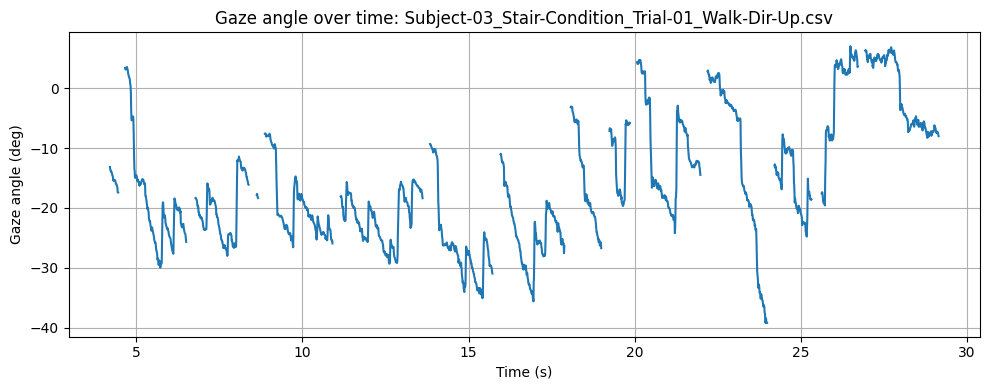

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from ipywidgets import Dropdown
from IPython.display import display, clear_output

SUBJECT_ID = None

# ------------------------------------------------------------------
# DISCOVER CSV FILES
# ------------------------------------------------------------------
if not os.path.isdir(OUTPUT_DIR):
    raise FileNotFoundError(f"Folder '{OUTPUT_DIR}' not found. "
                            f"Make sure it exists and contains your trial CSVs.")

all_csvs = [f for f in os.listdir(OUTPUT_DIR) if f.endswith(".csv")]

if SUBJECT_ID is not None:
    csv_files = sorted(f for f in all_csvs if f.startswith(SUBJECT_ID))
else:
    csv_files = sorted(all_csvs)

if not csv_files:
    raise RuntimeError(
        f"No CSV files found in '{OUTPUT_DIR}' "
        f"{'(with prefix ' + SUBJECT_ID + ')' if SUBJECT_ID else ''}."
    )

# ------------------------------------------------------------------
# WIDGET + PLOT LOGIC
# ------------------------------------------------------------------
dropdown = Dropdown(
    options=csv_files,
    value=csv_files[0],
    description="Segment:",
    style={"description_width": "initial"},
    layout={"width": "400px"}
)

def plot_segment(change):
    if change["name"] != "value" or change["new"] is None:
        return

    filename = change["new"]
    filepath = os.path.join(OUTPUT_DIR, filename)

    clear_output(wait=True)
    display(dropdown)  # re-display widget after clearing

    df = pd.read_csv(filepath)

    if "timestamp [ns]" not in df.columns or "gaze angle [deg]" not in df.columns:
        print(f"File '{filename}' is missing required columns.")
        return


    plt.figure(figsize=(10, 4))
    plt.plot(df["time_sec"], df["gaze angle [deg]"])
    plt.xlabel("Time (s)")
    plt.ylabel("Gaze angle (deg)")
    plt.title(f"Gaze angle over time: {filename}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call once for initial plot
dropdown.observe(plot_segment, names="value")
display(dropdown)
plot_segment({"name": "value", "new": dropdown.value})